# Preprocessing RZSM ERA5-Land untuk Penelitian Flash Drought Indonesia

Notebook ini menyiapkan data **SWVL1–SWVL3** hingga menjadi:

1. data **Root-Zone Soil Moisture (RZSM) 0–100 cm** berbobot kedalaman;
2. data harian;
3. data **73 pentad kalender per tahun**;
4. persentil kelembapan tanah dengan **Gringorten plotting position** untuk setiap grid dan setiap pentad kalender;
5. keluaran NetCDF yang siap digunakan pada tahap deteksi flash drought.

## Catatan penting tentang “1–2 pentad”

“Onset flash drought berlangsung 1–2 pentad” tidak selalu berarti seluruh kejadian hanya berlangsung 5–10 hari.  
Dalam metode berbasis soil-moisture percentile, **onset stage** adalah waktu penurunan cepat menuju kondisi drought, sedangkan **event duration** dapat berlanjut lebih lama hingga kelembapan tanah pulih. Karena itu, onset 1–2 pentad masih dapat memenuhi durasi minimum kejadian, misalnya 4 pentad.

Notebook ini belum menetapkan kejadian flash drought. Tahap deteksi dilakukan setelah struktur, kualitas, dan persentil data diperiksa.


**Versi 2:** pembukaan file diperbaiki untuk arsip bulanan terpisah (`swvl1_YYYY_MM.nc`, `swvl2_YYYY_MM.nc`, `swvl3_YYYY_MM.nc`) dan ketidakseragaman koordinat `expver`.

## 0. Instalasi paket

Jalankan sel berikut hanya apabila paket belum tersedia. Setelah instalasi, restart kernel bila diperlukan.


In [ ]:
# Hapus tanda pagar di baris berikut bila paket belum tersedia.
# %pip install xarray netCDF4 h5netcdf dask bottleneck scipy pandas numpy matplotlib


## 1. Impor pustaka

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

warnings.filterwarnings("once")

print("xarray :", xr.__version__)
print("numpy  :", np.__version__)
print("pandas :", pd.__version__)


xarray : 2026.7.0
numpy  : 2.5.0
pandas : 3.0.3


In [2]:
# Diagnostik lingkungan Python.
# RuntimeWarning tentang binary incompatibility berasal dari paket
# terkompilasi yang tidak cocok dengan versi NumPy aktif.
import sys

print("Python executable:", sys.executable)
print("Python version   :", sys.version.split()[0])

packages_to_check = [
    "numpy",
    "pandas",
    "scipy",
    "xarray",
    "dask",
    "netCDF4",
    "h5py",
    "h5netcdf",
    "bottleneck",
]

for package_name in packages_to_check:
    try:
        module = __import__(package_name)
        print(
            f"{package_name:10s}: "
            f"{getattr(module, '__version__', 'unknown')}"
        )
    except Exception as exc:
        print(
            f"{package_name:10s}: ERROR "
            f"{type(exc).__name__}: {exc}"
        )


Python executable: c:\Users\User\anaconda3\envs\era5\python.exe
Python version   : 3.12.13
numpy     : 2.5.0
pandas    : 3.0.3
scipy     : 1.18.0
xarray    : 2026.7.0
dask      : 2026.7.1
netCDF4   : 1.7.4
h5py      : 3.16.0
h5netcdf  : 1.8.1
bottleneck: 1.4.2


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


## 2. Konfigurasi

Ubah `DATA_DIR` sesuai lokasi file NetCDF. Notebook dapat membaca:

- satu file yang berisi SWVL1–SWVL3;
- file terpisah untuk setiap variabel;
- beberapa file yang dipisahkan berdasarkan bulan atau tahun.

Contoh Windows:

```python
DATA_DIR = Path(r"D:\ERA5_Land\soil_moisture")
```

Contoh Linux:

```python
DATA_DIR = Path("/home/hany/data/era5_land")
```


In [10]:
# =========================
# KONFIGURASI PENGGUNA
# =========================
DATA_DIR = Path(r"D:\ERA5_LAND\SW")
FILE_PATTERN = "*.nc"

OUTPUT_DIR = Path("D:\ERA5_LAND\output_rzsm")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Potong wilayah Indonesia dan sekitarnya setelah data dibuka.
CLIP_TO_INDONESIA = True
BBOX = {
    "lon_min": 90.0,
    "lon_max": 145.0,
    "lat_min": -15.0,
    "lat_max": 10.0,
}

# Biarkan xarray/Dask memilih chunk awal berdasarkan struktur file.
# Ini menghindari peringatan karena chunk latitude/longitude dipotong
# di tengah chunk bawaan NetCDF. Rechunk dapat dilakukan setelah data dibuka.
OPEN_CHUNKS = "auto"

# Syarat kelengkapan data hourly untuk membentuk rata-rata harian.
# Gunakan 24 untuk QC ketat. Ubah menjadi 20 hanya bila ada missing kecil
# dan keputusan tersebut sudah didokumentasikan.
MIN_VALID_HOURS_PER_DAY = 24

# Tahun kabisat dibuat menjadi 365 hari dengan menghapus 29 Februari.
DROP_FEB29 = True

# Pilihan penyimpanan.
SAVE_DAILY = False       # Data harian dapat berukuran besar.
SAVE_PENTAD = True
SAVE_PERCENTILE = True

print("Input :", DATA_DIR.resolve())
print("Output:", OUTPUT_DIR.resolve())


Input : D:\ERA5_LAND\SW
Output: D:\ERA5_LAND\output_rzsm


## 3. Temukan dan buka seluruh file

In [12]:
# File dikelompokkan berdasarkan variabel karena setiap file hanya
# memuat satu lapisan soil moisture.
FILE_PATTERNS = {
    "swvl1": "swvl1_????_??.nc",
    "swvl2": "swvl2_????_??.nc",
    "swvl3": "swvl3_????_??.nc",
}

variable_files = {
    var: sorted(DATA_DIR.rglob(pattern))
    for var, pattern in FILE_PATTERNS.items()
}

for var, var_files in variable_files.items():
    if not var_files:
        raise FileNotFoundError(
            f"Tidak ditemukan file {FILE_PATTERNS[var]!r} "
            f"di {DATA_DIR.resolve()}"
        )

    print(f"{var}: {len(var_files)} file")
    print("  pertama:", var_files[0].name)
    print("  terakhir:", var_files[-1].name)

# Periode 1995–2025 lengkap seharusnya memiliki 31 × 12 = 372 file
# untuk setiap variabel. Ini hanya pemeriksaan, bukan syarat mutlak.
expected_count = (2025 - 1995 + 1) * 12
for var, var_files in variable_files.items():
    if len(var_files) != expected_count:
        print(
            f"PERINGATAN {var}: ditemukan {len(var_files)} file, "
            f"sedangkan periode lengkap 1995–2025 adalah {expected_count} file."
        )


swvl1: 372 file
  pertama: swvl1_1995_01.nc
  terakhir: swvl1_2025_12.nc
swvl2: 372 file
  pertama: swvl2_1995_01.nc
  terakhir: swvl2_2025_12.nc
swvl3: 372 file
  pertama: swvl3_1995_01.nc
  terakhir: swvl3_2025_12.nc


In [13]:
def normalize_coordinate_names(ds: xr.Dataset) -> xr.Dataset:
    """Menyeragamkan nama koordinat menjadi time, latitude, longitude."""
    rename_map = {}

    candidates = {
        "time": ["time", "valid_time", "date"],
        "latitude": ["latitude", "lat", "y"],
        "longitude": ["longitude", "lon", "x"],
    }

    existing = set(ds.dims) | set(ds.coords)

    for target, aliases in candidates.items():
        if target in existing:
            continue

        found = next((name for name in aliases if name in existing), None)
        if found is not None and found != target:
            rename_map[found] = target

    if rename_map:
        ds = ds.rename(rename_map)

    required = {"time", "latitude", "longitude"}
    missing = required - (set(ds.dims) | set(ds.coords))

    if missing:
        raise KeyError(
            f"Koordinat wajib tidak ditemukan: {sorted(missing)}. "
            f"Koordinat tersedia: {list(ds.coords)}; "
            f"dimensi: {list(ds.dims)}"
        )

    return ds


def collapse_and_remove_expver(ds: xr.Dataset) -> xr.Dataset:
    """
    Mengatasi file ERA5 yang sebagian memiliki dimensi/koordinat expver
    dan sebagian tidak.

    Jika expver merupakan dimensi, nilai valid dari seluruh expver
    digabungkan dengan combine_first. Setelah itu koordinat expver dihapus.
    """
    if "expver" in ds.dims:
        merged = ds.isel(expver=0, drop=True)

        for i in range(1, ds.sizes["expver"]):
            merged = merged.combine_first(
                ds.isel(expver=i, drop=True)
            )

        ds = merged

    # expver kadang tersisa sebagai koordinat skalar.
    if "expver" in ds.coords:
        ds = ds.drop_vars("expver")

    return ds


def select_target_variable(
    ds: xr.Dataset,
    target: str,
) -> xr.Dataset:
    """
    Memilih variabel target. Jika nama internal NetCDF berbeda tetapi
    hanya ada satu data variable, variabel tersebut diganti namanya.
    """
    if target in ds.data_vars:
        return ds[[target]]

    lower_lookup = {
        name.lower(): name
        for name in ds.data_vars
    }

    if target.lower() in lower_lookup:
        actual = lower_lookup[target.lower()]
        return ds[[actual]].rename({actual: target})

    data_vars = list(ds.data_vars)

    if len(data_vars) == 1:
        actual = data_vars[0]
        print(
            f"Catatan: variabel internal {actual!r} "
            f"diganti menjadi {target!r}."
        )
        return ds[[actual]].rename({actual: target})

    raise KeyError(
        f"Variabel {target!r} tidak ditemukan. "
        f"Data variables dalam file: {data_vars}"
    )


def make_preprocess(target: str):
    """
    Fungsi ini dijalankan untuk SETIAP file sebelum xarray mencoba
    menggabungkan file-file bulanan.
    """
    def preprocess(ds: xr.Dataset) -> xr.Dataset:
        ds = normalize_coordinate_names(ds)
        ds = collapse_and_remove_expver(ds)
        ds = select_target_variable(ds, target)
        return ds

    return preprocess


def open_one_variable(
    target: str,
    paths: list[Path],
) -> xr.Dataset:
    """Membuka seluruh file bulanan untuk satu variabel."""
    print(f"\nMembuka {target}: {len(paths)} file ...")

    ds_var = xr.open_mfdataset(
        [str(path) for path in paths],
        combine="by_coords",
        preprocess=make_preprocess(target),
        chunks=OPEN_CHUNKS,
        parallel=False,
        data_vars="minimal",
        coords="minimal",
        compat="override",
        join="exact",
        combine_attrs="override",
    )

    ds_var = ds_var.sortby("time")
    ds_var = ds_var.sortby("latitude")
    ds_var = ds_var.sortby("longitude")

    # Hapus timestamp duplikat bila ada.
    time_index = pd.DatetimeIndex(ds_var["time"].values)
    duplicate_count = int(time_index.duplicated().sum())

    if duplicate_count:
        print(
            f"PERINGATAN {target}: {duplicate_count} timestamp "
            "duplikat; nilai pertama dipertahankan."
        )
        keep = ~time_index.duplicated(keep="first")
        ds_var = ds_var.isel(
            time=np.flatnonzero(keep)
        )

    if CLIP_TO_INDONESIA:
        ds_var = ds_var.sel(
            longitude=slice(
                BBOX["lon_min"],
                BBOX["lon_max"],
            ),
            latitude=slice(
                BBOX["lat_min"],
                BBOX["lat_max"],
            ),
        )

    print(
        f"{target} selesai | "
        f"time={ds_var.sizes['time']}, "
        f"latitude={ds_var.sizes['latitude']}, "
        f"longitude={ds_var.sizes['longitude']}"
    )

    return ds_var


# ============================================================
# BUKA KETIGA VARIABEL
# ============================================================

datasets = {
    var: open_one_variable(var, variable_files[var])
    for var in ["swvl1", "swvl2", "swvl3"]
}


# ============================================================
# BUAT SUMBU WAKTU HOURLY LENGKAP 1995–2025
# ============================================================

full_time = pd.date_range(
    start="1995-01-01 00:00:00",
    end="2025-12-31 23:00:00",
    freq="h",
    name="time",
)

print("\nJumlah waktu hourly yang seharusnya:", len(full_time))


# ============================================================
# PERIKSA MISSING TIME SETIAP VARIABEL
# ============================================================

missing_report = {}

for var, ds_var in datasets.items():

    current_time = pd.DatetimeIndex(
        ds_var["time"].values
    )

    missing_time = full_time.difference(current_time)
    extra_time = current_time.difference(full_time)

    missing_report[var] = missing_time

    print(f"\n{var}")
    print("  waktu tersedia :", len(current_time))
    print("  waktu hilang   :", len(missing_time))
    print("  waktu tambahan :", len(extra_time))

    if len(missing_time) > 0:
        print("  contoh waktu hilang:")
        print(list(missing_time[:10]))

        # Simpan daftar seluruh timestamp yang hilang.
        missing_df = pd.DataFrame({
            "missing_time": missing_time
        })

        missing_df["year"] = missing_df["missing_time"].dt.year
        missing_df["month"] = missing_df["missing_time"].dt.month
        missing_df["day"] = missing_df["missing_time"].dt.day

        detail_path = (
            OUTPUT_DIR
            / f"{var}_missing_hourly_detail.csv"
        )

        missing_df.to_csv(
            detail_path,
            index=False,
        )

        # Ringkasan jumlah missing per bulan.
        monthly_summary = (
            missing_df
            .groupby(["year", "month"])
            .size()
            .reset_index(name="missing_hours")
        )

        summary_path = (
            OUTPUT_DIR
            / f"{var}_missing_hourly_by_month.csv"
        )

        monthly_summary.to_csv(
            summary_path,
            index=False,
        )

        print("  laporan detail :", detail_path)
        print("  ringkasan bulan:", summary_path)

    if len(extra_time) > 0:
        raise ValueError(
            f"{var} memiliki timestamp di luar "
            "periode 1995–2025."
        )


# ============================================================
# PASTIKAN KOORDINAT SPASIAL IDENTIK
# ============================================================

reference = datasets["swvl1"]

for var in ["swvl2", "swvl3"]:

    lat_equal = np.array_equal(
        reference["latitude"].values,
        datasets[var]["latitude"].values,
    )

    lon_equal = np.array_equal(
        reference["longitude"].values,
        datasets[var]["longitude"].values,
    )

    if not lat_equal:
        raise ValueError(
            f"Koordinat latitude {var} berbeda "
            "dengan SWVL1."
        )

    if not lon_equal:
        raise ValueError(
            f"Koordinat longitude {var} berbeda "
            "dengan SWVL1."
        )

print("\nKoordinat latitude dan longitude identik.")


# ============================================================
# REINDEX KE WAKTU LENGKAP
#
# Timestamp yang tidak tersedia akan menjadi NaN.
# Tidak dilakukan interpolasi atau pengisian otomatis.
# ============================================================

datasets_aligned = {}

for var, ds_var in datasets.items():

    datasets_aligned[var] = ds_var.reindex(
        time=full_time
    )

    print(
        f"{var} setelah reindex:",
        dict(datasets_aligned[var].sizes)
    )


# ============================================================
# GABUNGKAN SWVL1, SWVL2, DAN SWVL3
# ============================================================

ds = xr.merge(
    [
        datasets_aligned["swvl1"],
        datasets_aligned["swvl2"],
        datasets_aligned["swvl3"],
    ],
    join="exact",
    compat="override",
    combine_attrs="override",
)

print("\nDataset gabungan berhasil:")
print(ds)

# join="exact" sengaja digunakan agar perbedaan koordinat antar-lapisan
# tidak disembunyikan melalui outer join yang menghasilkan NaN tambahan.




Membuka swvl1: 372 file ...
swvl1 selesai | time=271752, latitude=171, longitude=461

Membuka swvl2: 372 file ...
swvl2 selesai | time=271752, latitude=171, longitude=461

Membuka swvl3: 372 file ...
swvl3 selesai | time=271752, latitude=171, longitude=461

Jumlah waktu hourly yang seharusnya: 271752

swvl1
  waktu tersedia : 271752
  waktu hilang   : 0
  waktu tambahan : 0

swvl2
  waktu tersedia : 271752
  waktu hilang   : 0
  waktu tambahan : 0

swvl3
  waktu tersedia : 271752
  waktu hilang   : 0
  waktu tambahan : 0

Koordinat latitude dan longitude identik.
swvl1 setelah reindex: {'time': 271752, 'latitude': 171, 'longitude': 461}
swvl2 setelah reindex: {'time': 271752, 'latitude': 171, 'longitude': 461}
swvl3 setelah reindex: {'time': 271752, 'latitude': 171, 'longitude': 461}

Dataset gabungan berhasil:
<xarray.Dataset> Size: 257GB
Dimensions:    (time: 271752, latitude: 171, longitude: 461)
Coordinates:
  * time       (time) datetime64[ns] 2MB 1995-01-01 ... 2025-12-31T23:00:

## 4. Identifikasi variabel SWVL1–SWVL3

Nama variabel ERA5-Land umumnya `swvl1`, `swvl2`, dan `swvl3`.  
Fungsi berikut juga mencoba beberapa nama alternatif.


In [14]:
required_variables = ["swvl1", "swvl2", "swvl3"]
missing_variables = [
    var for var in required_variables
    if var not in ds.data_vars
]

if missing_variables:
    raise KeyError(
        f"Variabel wajib tidak ditemukan: {missing_variables}. "
        f"Variabel tersedia: {list(ds.data_vars)}"
    )

var_names = {
    "swvl1": "swvl1",
    "swvl2": "swvl2",
    "swvl3": "swvl3",
}

print("Variabel yang digunakan:")
for key, name in var_names.items():
    print(
        f"  {key}: {name} | "
        f"unit={ds[name].attrs.get('units', 'tidak tercantum')}"
    )


Variabel yang digunakan:
  swvl1: swvl1 | unit=m**3 m**-3
  swvl2: swvl2 | unit=m**3 m**-3
  swvl3: swvl3 | unit=m**3 m**-3


## 5. Quality control awal

In [15]:
# Pemeriksaan kontinuitas timestamp global.
time_index = pd.DatetimeIndex(ds["time"].values)

print("Waktu awal :", time_index.min())
print("Waktu akhir:", time_index.max())
print("Jumlah timestamp:", len(time_index))
print("Timestamp duplikat:", int(time_index.duplicated().sum()))

if len(time_index) >= 2:
    deltas = pd.Series(time_index[1:] - time_index[:-1]).value_counts().sort_index()
    print("\nDistribusi selisih waktu antartimestamp:")
    print(deltas.head(10))

    expected_hourly = pd.date_range(
        time_index.min(),
        time_index.max(),
        freq="h",
    )
    missing_global = expected_hourly.difference(time_index)
    print("\nJumlah timestamp hourly yang hilang secara global:", len(missing_global))
    if len(missing_global):
        print("Contoh timestamp hilang:", list(missing_global[:10]))


Waktu awal : 1995-01-01 00:00:00
Waktu akhir: 2025-12-31 23:00:00
Jumlah timestamp: 271752
Timestamp duplikat: 0

Distribusi selisih waktu antartimestamp:
0 days 01:00:00    271751
Name: count, dtype: int64

Jumlah timestamp hourly yang hilang secara global: 0


In [16]:
# Statistik sampel satu minggu pertama agar pemeriksaan awal cepat.
sample = ds[list(var_names.values())].isel(time=slice(0, min(168, ds.sizes["time"])))

for key, name in var_names.items():
    da = sample[name]
    vmin = float(da.min(skipna=True).compute())
    vmax = float(da.max(skipna=True).compute())
    missing_fraction = float(da.isnull().mean().compute())

    print(
        f"{key:5s} | min={vmin:.5f} | max={vmax:.5f} "
        f"| fraksi NaN sampel={missing_fraction:.4f}"
    )

print(
    "\nCatatan: nilai NaN di laut dapat normal bergantung pada format/mask data. "
    "Jangan langsung mengisi NaN sebelum memeriksa lokasinya."
)


swvl1 | min=0.01222 | max=0.61400 | fraksi NaN sampel=0.7707
swvl2 | min=0.10638 | max=0.61400 | fraksi NaN sampel=0.7707
swvl3 | min=0.05927 | max=0.61400 | fraksi NaN sampel=0.7707

Catatan: nilai NaN di laut dapat normal bergantung pada format/mask data. Jangan langsung mengisi NaN sebelum memeriksa lokasinya.


## 6. Bentuk Root-Zone Soil Moisture 0–100 cm

Ketebalan lapisan ERA5-Land yang digunakan:

- SWVL1: 0–7 cm → bobot 0.07
- SWVL2: 7–28 cm → bobot 0.21
- SWVL3: 28–100 cm → bobot 0.72

RZSM dihitung sebagai:

\[
RZSM = 0.07(SWVL1) + 0.21(SWVL2) + 0.72(SWVL3)
\]

Bobot berjumlah satu dan mewakili rata-rata volumetrik pada kedalaman 0–100 cm.


In [17]:
swvl1 = ds[var_names["swvl1"]]
swvl2 = ds[var_names["swvl2"]]
swvl3 = ds[var_names["swvl3"]]

weights = {"swvl1": 0.07, "swvl2": 0.21, "swvl3": 0.72}
assert np.isclose(sum(weights.values()), 1.0)

rzsm_hourly = (
    weights["swvl1"] * swvl1
    + weights["swvl2"] * swvl2
    + weights["swvl3"] * swvl3
)

rzsm_hourly = rzsm_hourly.rename("rzsm")
rzsm_hourly.attrs.update({
    "long_name": "Depth-weighted root-zone soil moisture, 0-100 cm",
    "units": swvl1.attrs.get("units", "m3 m-3"),
    "formula": "0.07*SWVL1 + 0.21*SWVL2 + 0.72*SWVL3",
    "source_variables": ", ".join(var_names.values()),
})

rzsm_hourly


<xarray.DataArray 'rzsm' (time: 271752, latitude: 171, longitude: 461)> Size: 86GB
dask.array<add, shape=(271752, 171, 461), dtype=float32, chunksize=(496, 85, 308), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2MB 1995-01-01 ... 2025-12-31T23:00:00
  * latitude   (latitude) float64 1kB -11.0 -10.9 -10.8 -10.7 ... 5.8 5.9 6.0
  * longitude  (longitude) float64 4kB 95.0 95.1 95.2 95.3 ... 140.8 140.9 141.0
    number     int64 8B ...
Attributes: (12/34)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      78831
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_name:                                Volumetric soil water layer 3
    GRIB_shortName:                           swvl3
    long_name:                                Depth-weighted root-zone soil m...
    GRIB_depthBelowLandLayer:                 28.0
    formula:                                  0.07*SWVL1 + 0.21*SWVL2 + 0.72*...
    source_variables:                         swvl1, swvl2, swvl3

## 7. Konversi hourly → daily

In [18]:
# Rata-rata harian dan jumlah observasi valid per grid per hari.
daily_count = rzsm_hourly.resample(time="1D").count()
rzsm_daily = rzsm_hourly.resample(time="1D").mean(skipna=True)

# Hari yang tidak memenuhi jumlah jam valid minimum dijadikan NaN.
rzsm_daily = rzsm_daily.where(daily_count >= MIN_VALID_HOURS_PER_DAY)
rzsm_daily = rzsm_daily.rename("rzsm")

rzsm_daily.attrs.update(rzsm_hourly.attrs)
rzsm_daily.attrs["temporal_aggregation"] = (
    f"daily mean; minimum {MIN_VALID_HOURS_PER_DAY} valid hourly values"
)

print(rzsm_daily)


<xarray.DataArray 'rzsm' (time: 11323, latitude: 171, longitude: 461)> Size: 4GB
dask.array<where, shape=(11323, 171, 461), dtype=float32, chunksize=(1, 85, 308), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 91kB 1995-01-01 1995-01-02 ... 2025-12-31
  * latitude   (latitude) float64 1kB -11.0 -10.9 -10.8 -10.7 ... 5.8 5.9 6.0
  * longitude  (longitude) float64 4kB 95.0 95.1 95.2 95.3 ... 140.8 140.9 141.0
    number     int64 8B ...
Attributes: (12/35)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      78831
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_shortName:                           swvl3
    long_name:                                Depth-weighted root-zone soil m...
    

## 8. Penanganan tahun kabisat

Untuk menghasilkan **365 hari dan 73 pentad pada setiap tahun**, tanggal **29 Februari dihapus**.  
Setelah itu, pentad dihitung ulang dari urutan hari dalam setiap tahun:

- Pentad 1 = hari 1–5
- Pentad 2 = hari 6–10
- ...
- Pentad 73 = hari 361–365

Keputusan ini harus ditulis eksplisit dalam metode penelitian karena dapat memengaruhi posisi kalender setelah Februari pada tahun kabisat.


In [19]:
if DROP_FEB29:
    feb29 = (
        (rzsm_daily["time"].dt.month == 2)
        & (rzsm_daily["time"].dt.day == 29)
    )
    rzsm_daily = rzsm_daily.where(~feb29, drop=True)

days_per_year = rzsm_daily["time"].groupby("time.year").count()
print(days_per_year.to_series())

bad_years = days_per_year.where(days_per_year != 365, drop=True)
if bad_years.size:
    raise ValueError(
        "Terdapat tahun yang tidak memiliki tepat 365 timestamp harian setelah "
        f"penanganan tahun kabisat:\n{bad_years.to_series()}"
    )

print("\nSemua tahun memiliki 365 tanggal harian.")


year
1995    365
1996    365
1997    365
1998    365
1999    365
2000    365
2001    365
2002    365
2003    365
2004    365
2005    365
2006    365
2007    365
2008    365
2009    365
2010    365
2011    365
2012    365
2013    365
2014    365
2015    365
2016    365
2017    365
2018    365
2019    365
2020    365
2021    365
2022    365
2023    365
2024    365
2025    365
Name: time, dtype: int64

Semua tahun memiliki 365 tanggal harian.


## 9. Konversi daily → 73 pentad per tahun

In [20]:
def daily_to_fixed_pentad(da: xr.DataArray) -> xr.DataArray:
    """
    Mengubah data harian 365 hari/tahun menjadi 73 pentad non-overlapping.
    Setiap pentad terdiri dari tepat 5 hari.
    """
    outputs = []
    years = np.unique(da["time"].dt.year.values)

    for year in years:
        yearly = da.sel(time=str(int(year)))

        if yearly.sizes["time"] != 365:
            raise ValueError(
                f"Tahun {year} memiliki {yearly.sizes['time']} hari, bukan 365."
            )

        pentad_number = (np.arange(365) // 5 + 1).astype(np.int16)
        yearly = yearly.assign_coords(
            pentad=("time", pentad_number)
        )

        pentad_mean = yearly.groupby("pentad").mean(
            dim="time",
            skipna=True,
        )

        # Jumlah hari valid per grid dalam setiap pentad.
        pentad_count = yearly.groupby("pentad").count(dim="time")

        # QC ketat: pentad harus memiliki 5 hari valid pada grid tersebut.
        pentad_mean = pentad_mean.where(pentad_count == 5)

        pentad_mean = pentad_mean.expand_dims(year=[int(year)])
        outputs.append(pentad_mean)

    result = xr.concat(outputs, dim="year")
    result = result.transpose(
        "year",
        "pentad",
        *[d for d in result.dims if d not in {"year", "pentad"}],
    )

    result = result.assign_coords(
        pentad_start_doy=(
            "pentad",
            ((result["pentad"].values - 1) * 5 + 1).astype(np.int16),
        ),
        pentad_end_doy=(
            "pentad",
            (result["pentad"].values * 5).astype(np.int16),
        ),
    )

    return result


rzsm_pentad = daily_to_fixed_pentad(rzsm_daily)
rzsm_pentad = rzsm_pentad.rename("rzsm")

rzsm_pentad.attrs.update(rzsm_hourly.attrs)
rzsm_pentad.attrs["temporal_aggregation"] = (
    "fixed non-overlapping 5-day means; 73 pentads per 365-day year; "
    "29 February removed"
)

print(rzsm_pentad)
print("\nUkuran dimensi:", dict(rzsm_pentad.sizes))

assert rzsm_pentad.sizes["pentad"] == 73


<xarray.DataArray 'rzsm' (year: 31, pentad: 73, latitude: 171, longitude: 461)> Size: 714MB
dask.array<concatenate, shape=(31, 73, 171, 461), dtype=float32, chunksize=(1, 1, 85, 308), chunktype=numpy.ndarray>
Coordinates:
  * year              (year) int64 248B 1995 1996 1997 1998 ... 2023 2024 2025
  * pentad            (pentad) int16 146B 1 2 3 4 5 6 7 ... 67 68 69 70 71 72 73
    pentad_start_doy  (pentad) int16 146B 1 6 11 16 21 ... 341 346 351 356 361
    pentad_end_doy    (pentad) int16 146B 5 10 15 20 25 ... 345 350 355 360 365
  * latitude          (latitude) float64 1kB -11.0 -10.9 -10.8 ... 5.8 5.9 6.0
  * longitude         (longitude) float64 4kB 95.0 95.1 95.2 ... 140.9 141.0
    number            int64 8B 0
Attributes: (12/35)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      78831
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                 

## 10. Persentil Gringorten per grid dan pentad kalender

Untuk setiap kombinasi **pentad × latitude × longitude**, nilai dari seluruh tahun diurutkan.  
Posisi probabilitas Gringorten dihitung dengan:

\[
P = 100 \times \frac{r - 0.44}{n + 0.12}
\]

dengan:

- \(r\) = rank nilai RZSM pada dimensi tahun;
- \(n\) = jumlah tahun valid.

Dengan cara ini, kondisi tanah dibandingkan dengan pentad kalender yang sama, bukan dengan seluruh hari dalam setahun.


In [21]:
def gringorten_percentile(
    da: xr.DataArray,
    dim: str = "year",
    min_samples: int = 20,
) -> xr.DataArray:
    """Menghitung percentile rank Gringorten pada dimensi tertentu."""
    if dim not in da.dims:
        raise ValueError(f"Dimensi {dim!r} tidak terdapat pada data.")

    # Dimensi rank harus berada dalam satu chunk untuk operasi rank.
    if da.chunks is not None:
        da = da.chunk({dim: -1})

    n = da.count(dim=dim)
    rank = da.rank(dim=dim, pct=False)

    percentile = 100.0 * (rank - 0.44) / (n + 0.12)
    percentile = percentile.where(n >= min_samples)

    percentile = percentile.rename("rzsm_percentile")
    percentile.attrs.update({
        "long_name": "Root-zone soil moisture percentile",
        "units": "percent",
        "plotting_position": "Gringorten: 100*(rank-0.44)/(n+0.12)",
        "reference_dimension": dim,
        "minimum_valid_samples": min_samples,
    })

    return percentile


rzsm_percentile = gringorten_percentile(
    rzsm_pentad,
    dim="year",
    min_samples=20,
)

n_valid_years = rzsm_pentad.count("year").rename("n_valid_years")
n_valid_years.attrs.update({
    "long_name": "Number of valid years used for pentad climatology",
    "units": "year",
})

print(rzsm_percentile)


<xarray.DataArray 'rzsm_percentile' (year: 31, pentad: 73, latitude: 171,
                                     longitude: 461)> Size: 1GB
dask.array<where, shape=(31, 73, 171, 461), dtype=float64, chunksize=(31, 1, 85, 308), chunktype=numpy.ndarray>
Coordinates:
  * year              (year) int64 248B 1995 1996 1997 1998 ... 2023 2024 2025
  * pentad            (pentad) int16 146B 1 2 3 4 5 6 7 ... 67 68 69 70 71 72 73
    pentad_start_doy  (pentad) int16 146B dask.array<chunksize=(73,), meta=np.ndarray>
    pentad_end_doy    (pentad) int16 146B dask.array<chunksize=(73,), meta=np.ndarray>
  * latitude          (latitude) float64 1kB -11.0 -10.9 -10.8 ... 5.8 5.9 6.0
  * longitude         (longitude) float64 4kB 95.0 95.1 95.2 ... 140.9 141.0
    number            int64 8B 0
Attributes: (12/38)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      78831
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:        

## 11. Pemeriksaan hasil persentil

In [22]:
# Ringkasan global dapat memerlukan waktu karena memicu komputasi Dask.
pct_min = float(rzsm_percentile.min(skipna=True).compute())
pct_max = float(rzsm_percentile.max(skipna=True).compute())

print(f"Persentil minimum: {pct_min:.3f}")
print(f"Persentil maksimum: {pct_max:.3f}")
print("Rentang tidak harus tepat 0–100 karena rumus plotting position Gringorten.")


Persentil minimum: 1.799
Persentil maksimum: 98.201
Rentang tidak harus tepat 0–100 karena rumus plotting position Gringorten.


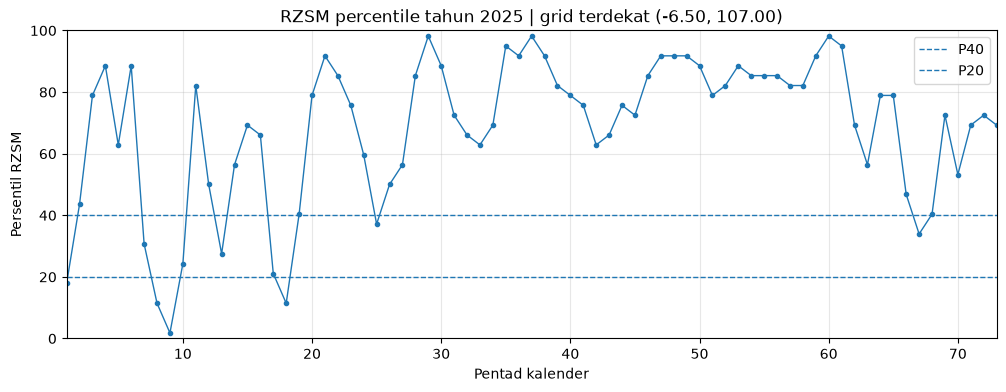

In [23]:
# Pilih satu titik contoh di sekitar Jawa untuk inspeksi.
POINT_LAT = -6.5
POINT_LON = 107.0
EXAMPLE_YEAR = int(rzsm_pentad["year"].values[-1])

point_rzsm = rzsm_pentad.sel(
    latitude=POINT_LAT,
    longitude=POINT_LON,
    method="nearest",
)

point_pct = rzsm_percentile.sel(
    latitude=POINT_LAT,
    longitude=POINT_LON,
    method="nearest",
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    point_pct["pentad"],
    point_pct.sel(year=EXAMPLE_YEAR),
    marker="o",
    markersize=3,
    linewidth=1,
)
ax.axhline(40, linestyle="--", linewidth=1, label="P40")
ax.axhline(20, linestyle="--", linewidth=1, label="P20")
ax.set(
    title=(
        f"RZSM percentile tahun {EXAMPLE_YEAR} | "
        f"grid terdekat ({float(point_pct.latitude):.2f}, "
        f"{float(point_pct.longitude):.2f})"
    ),
    xlabel="Pentad kalender",
    ylabel="Persentil RZSM",
    xlim=(1, 73),
    ylim=(0, 100),
)
ax.grid(alpha=0.3)
ax.legend()
plt.show()


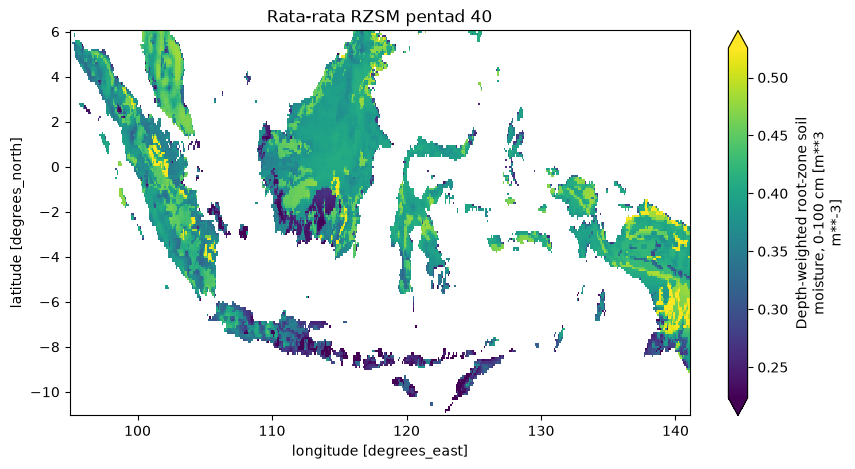

In [24]:
# Peta contoh RZSM rata-rata untuk satu pentad kalender.
EXAMPLE_PENTAD = 40

map_data = rzsm_pentad.sel(pentad=EXAMPLE_PENTAD).mean("year")

plt.figure(figsize=(10, 5))
map_data.plot(
    x="longitude",
    y="latitude",
    robust=True,
)
plt.title(f"Rata-rata RZSM pentad {EXAMPLE_PENTAD}")
plt.show()


## 12. Simpan keluaran

In [25]:
def default_encoding(var_name: str) -> dict:
    return {
        var_name: {
            "zlib": True,
            "complevel": 4,
            "shuffle": True,
            "dtype": "float32",
        }
    }


if SAVE_DAILY:
    daily_path = OUTPUT_DIR / "rzsm_daily_365day.nc"
    rzsm_daily.to_dataset().to_netcdf(
        daily_path,
        encoding=default_encoding("rzsm"),
    )
    print("Tersimpan:", daily_path.resolve())

if SAVE_PENTAD:
    pentad_path = OUTPUT_DIR / "rzsm_pentad_1995_2025.nc"
    rzsm_pentad.to_dataset().to_netcdf(
        pentad_path,
        encoding=default_encoding("rzsm"),
    )
    print("Tersimpan:", pentad_path.resolve())

if SAVE_PERCENTILE:
    percentile_path = OUTPUT_DIR / "rzsm_percentile_gringorten_1995_2025.nc"
    output_pct = xr.Dataset({
        "rzsm_percentile": rzsm_percentile,
        "n_valid_years": n_valid_years,
    })
    output_pct.to_netcdf(
        percentile_path,
        encoding={
            "rzsm_percentile": {
                "zlib": True,
                "complevel": 4,
                "shuffle": True,
                "dtype": "float32",
            },
            "n_valid_years": {
                "zlib": True,
                "complevel": 4,
                "shuffle": True,
                "dtype": "int16",
                "_FillValue": -9999,
            },
        },
    )
    print("Tersimpan:", percentile_path.resolve())


c:\Users\User\anaconda3\envs\era5\Lib\site-packages\xarray\backends\netCDF4_.py:96: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data[key] = value


Tersimpan: D:\ERA5_LAND\output_rzsm\rzsm_pentad_1995_2025.nc


c:\Users\User\anaconda3\envs\era5\Lib\site-packages\xarray\backends\netCDF4_.py:96: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  data[key] = value


Tersimpan: D:\ERA5_LAND\output_rzsm\rzsm_percentile_gringorten_1995_2025.nc


## 13. Checklist sebelum deteksi flash drought

Pastikan seluruh poin berikut terpenuhi:

- [✔] Rentang waktu sesuai 1995–2025.
- [✔] Tidak ada timestamp hourly yang hilang tanpa penjelasan.
- [✔] Semua tahun menjadi 365 hari setelah 29 Februari dihapus.
- [✔] Setiap tahun memiliki 73 pentad.
- [✔] RZSM menggunakan bobot 0.07, 0.21, dan 0.72.  
- [✔] Area laut atau grid non-valid tetap dimask, bukan diisi secara sembarang.

## Tahap berikutnya

Setelah output diperiksa, tahap deteksi dapat membedakan dengan jelas:

1. **onset time** — waktu penurunan cepat dari ≥P40 menuju <P20;
2. **onset speed** — perubahan percentile point per pentad;
3. **event duration** — periode drought sampai RZSM kembali melampaui P20;
4. **minimum duration filter** — misalnya 4 pentad untuk menghapus dry spell singkat;
5. **severity** — akumulasi defisit persentil selama kejadian;
6. **recovery time** — waktu dari minimum menuju terminasi.

Jangan menyamakan onset 1–2 pentad dengan total durasi kejadian.
